In [53]:
%load_ext autoreload
%autoreload 2
from qm.QuantumMachinesManager import QuantumMachinesManager
import qm.qua as q
from qualang_tools.results import progress_counter, fetching_tool
from qualang_tools.analysis.discriminator import two_state_discriminator
from importlib import reload
from jobqueue import JobQueue
import pyvisa
import numpy as np
import matplotlib.pyplot as plt
from qutip import Qobj
import h5py
import joblib
import json
from scipy.optimize import minimize
import matplotlib.colors as col
import seaborn as sns
import hsluv
import scipy.special
import itertools as it
from numpy import pi, array, sin, cos, angle, log2
from qutip.visualization import _cb_labels, _blob, _isqubitdims, _super_to_superpauli

# import opx_config_muninn_xingrui as cf
import opx_config_xiayu11_latest as cf
import matplotlib as mpl

import func

reload(cf)  # Necessary to make sure updated json
config = cf.config

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
# ACS_frequency = np.arange(4.10, 4.36, 0.01)  
ACS_frequency = np.linspace(4.10, 4.35, num=26)
Q1_delta_freq_array = np.array([456358, 440364, 479197, 457785, 382023, 405096, 817702, -2190954, -750987, -511354, -427594, -345728, -247638, -183449, -145183, -98772, -54644, -35016, -30891, -38599, -40378, -40025, -38624, -36081, -29740, -24528])
Q2_delta_freq_array = np.array([-596512, -756523, -1360695, 2114717, 1010825, 671982, 727803, 903658, 898561, 925287, 1064361, 1004260, 901459, 857606, 967765, 1163793, 1511051, 3548153, -2950243, -1592068, -1038679, -704298, -502514, -389556, -295553, -214057])
print(ACS_frequency)
print(len(ACS_frequency))
print(len(Q1_delta_freq_array))
print(len(Q2_delta_freq_array))

[4.1  4.11 4.12 4.13 4.14 4.15 4.16 4.17 4.18 4.19 4.2  4.21 4.22 4.23
 4.24 4.25 4.26 4.27 4.28 4.29 4.3  4.31 4.32 4.33 4.34 4.35]
26
26
26


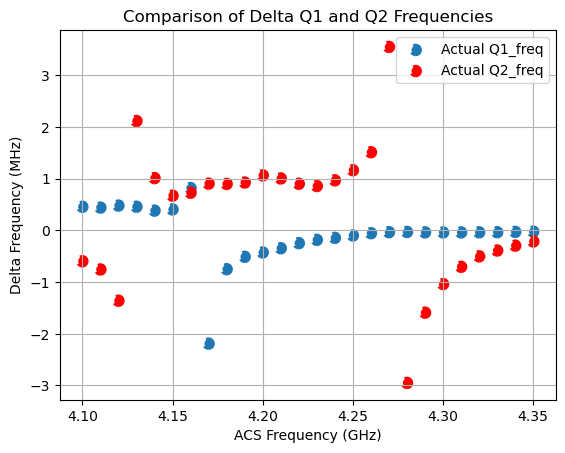

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Combined plot for Q1 and Q2
plt.figure()
# Plot Q1 data
plt.scatter(ACS_frequency, Q1_delta_freq_array * 10**-6, label='Actual Q1_freq', linestyle='--', linewidth=3)

# Plot Q2 data
plt.scatter(ACS_frequency, Q2_delta_freq_array * 10**-6, label='Actual Q2_freq', linestyle='--', linewidth=3, color='red')

# plt.ylim(-10.0, 10.0) 
# Add labels, title, legend, and grid
plt.xlabel('ACS Frequency (GHz)')
plt.ylabel('Delta Frequency (MHz)')
plt.title('Comparison of Delta Q1 and Q2 Frequencies')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ACS_frequency = np.arange(4.15, 4.31, 0.01)  # 4.31 is exclusive
# Q1_delta_freq_array = np.array([405096, 817702, -2190954, -750987, -511354, -427594])
# Q2_delta_freq_array = np.array([671982, 727803, 903658, 898561, 925287, 1064361])
# print(ACS_frequency)

In [31]:
import os
import pandas as pd
from datetime import datetime

# Generate the date suffix dynamically with hour and minute
date_suffix = datetime.now().strftime('%m%d')  # Format: MMDD

exp_name = 'ACS_f_sweep'

# Define the date as a variable
# date_suffix = '1212'  # Set your desired date suffix here

# Define your directory where you want to save the files
save_directory = cf.save_load_dir

# # Make sure the directory exists, if not, create it
# os.makedirs(save_directory, exist_ok=True)

# Convert lists or arrays into pandas DataFrames for saving
df_Q1_delta = pd.DataFrame(Q1_delta_freq_array, columns=['Q1_delta_freq'])
df_Q2_delta = pd.DataFrame(Q2_delta_freq_array, columns=['Q2_delta_freq'])
df_ACS_frequency = pd.DataFrame(ACS_frequency, columns=['ACS_frequency'])

# Save each DataFrame to a CSV file with the date suffix
df_Q1_delta.to_csv(os.path.join(save_directory, f'{exp_name}_Q1_delta_freq_array_{date_suffix}.csv'), index=False)
df_Q2_delta.to_csv(os.path.join(save_directory, f'{exp_name}_Q2_delta_freq_array_{date_suffix}.csv'), index=False)
df_ACS_frequency.to_csv(os.path.join(save_directory, f'{exp_name}_ACS_frequency_{date_suffix}.csv'), index=False)

print(f"Files have been saved to: {save_directory} with date suffix {date_suffix}")

Files have been saved to: C:/shared-root/users/Sean/xiayu11/calib_v6/Data with date suffix 0408


In [33]:
import os
import pandas as pd

# Define the directory where files are saved
load_directory = cf.save_load_dir  # Same as your save_directory

# Define the experiment name and date suffix
exp_name = 'ACS_f_sweep'
date_suffix = '0408'  # Replace this with the actual suffix used

# Construct the file paths
file_Q1_delta = os.path.join(load_directory, f'{exp_name}_Q1_delta_freq_array_{date_suffix}.csv')
file_Q2_delta = os.path.join(load_directory, f'{exp_name}_Q2_delta_freq_array_{date_suffix}.csv')
file_ACS_frequency = os.path.join(load_directory, f'{exp_name}_ACS_frequency_{date_suffix}.csv')
file_ACS_freq_abs_delta_matrix = os.path.join(load_directory, f'{exp_name}_ACS_freq_abs_delta_matrix_{date_suffix}.csv')

# Load the DataFrames from the CSV files
df_Q1_delta_loaded = pd.read_csv(file_Q1_delta)
df_Q2_delta_loaded = pd.read_csv(file_Q2_delta)
df_ACS_frequency_loaded = pd.read_csv(file_ACS_frequency)

# Display a quick summary to confirm loading
print("Q1 Delta Frequencies:")
print(df_Q1_delta_loaded.head())

print("\nQ2 Delta Frequencies:")
print(df_Q2_delta_loaded.head())

print("\nACS Frequencies:")
print(df_ACS_frequency_loaded.head())

Q1 Delta Frequencies:
   Q1_delta_freq
0         456358
1         440364
2         479197
3         457785
4         382023

Q2 Delta Frequencies:
   Q2_delta_freq
0        -596512
1        -756523
2       -1360695
3        2114717
4        1010825

ACS Frequencies:
   ACS_frequency
0           4.10
1           4.11
2           4.12
3           4.13
4           4.14


1.2298100492866835
0.06283260388627213


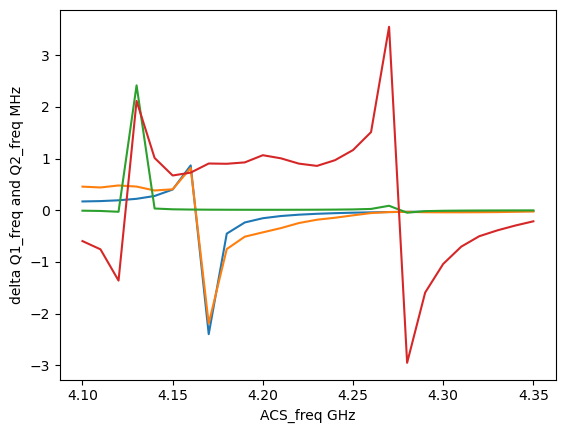

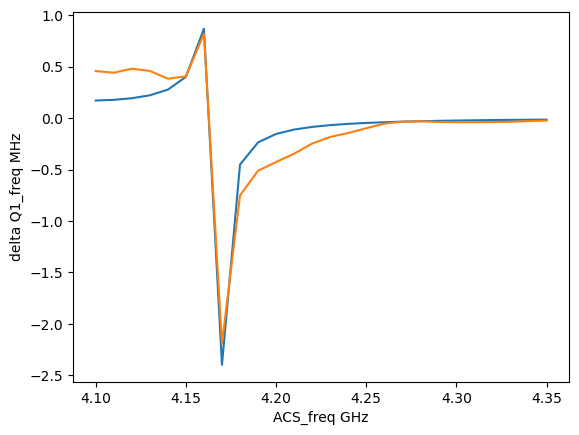

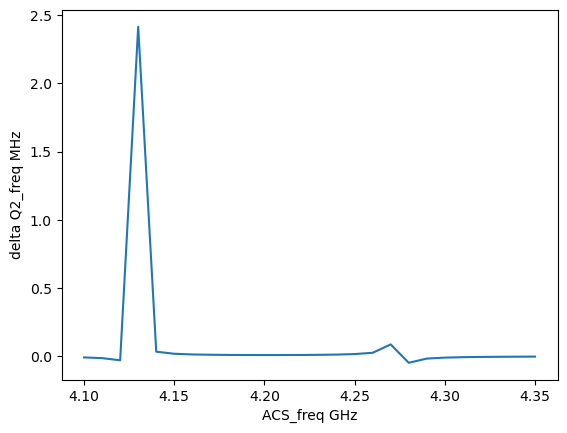

In [57]:
import os
import pandas as pd
from scipy.optimize import curve_fit

# Extract data as NumPy arrays
ACS_freq = df_ACS_frequency_loaded['ACS_frequency'].values * 1E9
Q1_delta_freq_array = df_Q1_delta_loaded['Q1_delta_freq'].values
Q2_delta_freq_array = df_Q2_delta_loaded['Q2_delta_freq'].values

def delta_Q_freq(ACS_freq, Q_freq, Q_ef_freq, scale_factor):
    #define anharmonicity
    alpha = Q_ef_freq - Q_freq
    delta_qs = Q_freq - ACS_freq
    delta_Q_freq = alpha * scale_factor / (2 * delta_qs * (alpha + delta_qs))
    return delta_Q_freq

scale_factor_Q1 = 1e13
scale_factor_Q2 = 1.5e13

from functools import partial

# For Q1
popt_Q1, pcov_Q1 = curve_fit(
    lambda ACS_freq, scale_factor: delta_Q_freq(ACS_freq, cf.Q1_freq, cf.Q1_ef_freq, scale_factor),
    ACS_freq,
    Q1_delta_freq_array,
    p0=[scale_factor_Q1]
)
scale_factor_Q1 = popt_Q1[0]

# For Q2
popt_Q2, pcov_Q2 = curve_fit(
    lambda ACS_freq, scale_factor: delta_Q_freq(ACS_freq, cf.Q2_freq, cf.Q2_ef_freq, scale_factor),
    ACS_freq,
    Q2_delta_freq_array,
    p0=[scale_factor_Q2]
)
scale_factor_Q2 = popt_Q2[0]

print(scale_factor_Q1 / (1e13))
print(scale_factor_Q2 / (1e13))


delta_Q1_freq = delta_Q_freq(ACS_freq, cf.Q1_freq, cf.Q1_ef_freq, scale_factor_Q1)
delta_Q2_freq = delta_Q_freq(ACS_freq, cf.Q2_freq, cf.Q2_ef_freq, scale_factor_Q2)

plt.plot(ACS_freq * 10**-9, delta_Q1_freq * 10**-6)
plt.plot(ACS_freq * 10**-9, Q1_delta_freq_array * 10**-6)
plt.plot(ACS_freq * 10**-9, delta_Q2_freq * 10**-6)
plt.plot(ACS_freq * 10**-9, Q2_delta_freq_array * 10**-6)
plt.xlabel('ACS_freq GHz')
plt.ylabel('delta Q1_freq and Q2_freq MHz')
plt.show()

plt.plot(ACS_freq * 10**-9, delta_Q1_freq * 10**-6)
plt.plot(ACS_freq * 10**-9, Q1_delta_freq_array * 10**-6)
plt.xlabel('ACS_freq GHz')
plt.ylabel('delta Q1_freq MHz')
plt.show()

plt.plot(ACS_freq * 10**-9, delta_Q2_freq * 10**-6)
# plt.plot(ACS_freq * 10**-9, Q2_delta_freq_array * 10**-6)
plt.xlabel('ACS_freq GHz')
plt.ylabel('delta Q2_freq MHz')
plt.show()

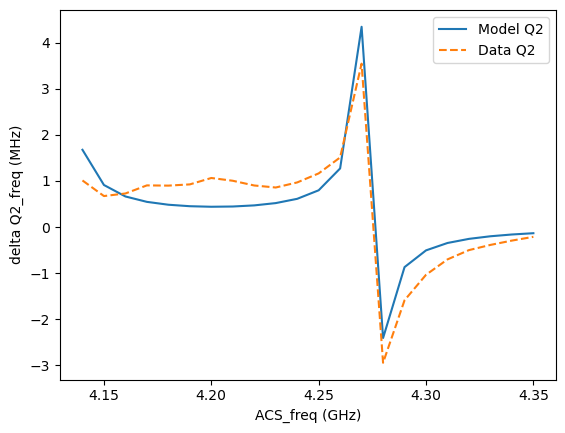

In [71]:
# Filter the data for ACS_freq > 4.20E9
filter_condition = ACS_freq > 4.13E9
ACS_freq_filtered = ACS_freq[filter_condition]
Q2_delta_freq_filtered = Q2_delta_freq_array[filter_condition]

# For Q2, perform curve fitting over the filtered range
popt_Q2, pcov_Q2 = curve_fit(
    lambda ACS_freq, scale_factor: delta_Q_freq(ACS_freq, cf.Q2_freq, cf.Q2_ef_freq, scale_factor),
    ACS_freq_filtered,
    Q2_delta_freq_filtered,
    p0=[scale_factor_Q2]
)

# Extract the optimized scale factor for Q2
scale_factor_Q2 = popt_Q2[0]

# Now calculate delta_Q2_freq for the filtered ACS_freq
delta_Q2_freq_filtered = delta_Q_freq(ACS_freq_filtered, cf.Q2_freq, cf.Q2_ef_freq, scale_factor_Q2)

# Plot the results for Q2 in the filtered range
plt.plot(ACS_freq_filtered * 10**-9, delta_Q2_freq_filtered * 10**-6, label='Model Q2')
plt.plot(ACS_freq_filtered * 10**-9, Q2_delta_freq_filtered * 10**-6, label='Data Q2', linestyle='--')
plt.xlabel('ACS_freq (GHz)')
plt.ylabel('delta Q2_freq (MHz)')
plt.legend()
plt.show()


In [72]:
import math

def calculate_omega_s(alpha1, alpha2, omega1, omega2, scale):
    # First part of the piecewise equation
    part = scale * alpha2 * omega1 + scale * alpha2 * (alpha1 + omega1) + alpha1 * omega2 + alpha1 * (alpha2 + omega2)
    sqrt_part1 = (-scale * alpha2 * omega1 - scale * alpha2 * (alpha1 + omega1) - alpha1 * omega2 - alpha1 * (alpha2 + omega2)) ** 2
    sqrt_part2 = - 4 * (alpha1 + scale * alpha2) * (alpha1 * omega2 * (alpha2 + omega2) + scale * alpha2 * omega1 * (alpha1 + omega1))
    sqrt_part = math.sqrt(sqrt_part1 + sqrt_part2)
    
    omega_s1 = (part - sqrt_part) / (2 * (alpha1 + scale * alpha2))
    omega_s2 = (part + sqrt_part) / (2 * (alpha1 + scale * alpha2))

    return omega_s1, omega_s2

# input values
Q1_freq = cf.Q1_freq
Q1_ef_freq = cf.Q1_ef_freq
Q2_freq = cf.Q2_freq
Q2_ef_freq = cf.Q2_ef_freq
ACS = cf.ACS_freq

alpha1 = Q1_ef_freq - Q1_freq
alpha2 = Q2_ef_freq - Q2_freq
omega1 = Q1_freq
omega2 = Q2_freq
scale = scale_factor_Q2 / scale_factor_Q1

omega_s1, omega_s2 = calculate_omega_s(alpha1, alpha2, omega1, omega2, scale)

print(f"Solution 1: omega_s = {omega_s1}")
print(f"Solution 2: omega_s = {omega_s2}")
print(ACS - omega_s1)

Solution 1: omega_s = 4179155850.0825396
Solution 2: omega_s = 4070813142.095759
-2157688.0825395584


C:\Users\crow104e3\AppData\Local\Temp\ipykernel_7536\2242085858.py:14: RuntimeWarning: divide by zero encountered in divide
  delta_Q_freq = alpha * scale_factor / (2 * delta_qs * (alpha + delta_qs))


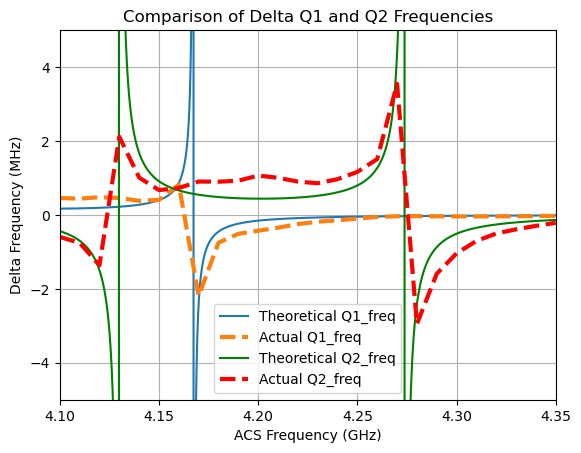

-487412.84610274143
487412.8461040362


In [73]:
import numpy as np
import matplotlib.pyplot as plt

# Define the frequency range for the new ACS_freq
freq_start = 4.0e9  # Start frequency in Hz
freq_end = 4.4e9    # End frequency in Hz
freq_step = 0.1e6   # Step size in Hz
ACS_freq_th = np.arange(freq_start, freq_end, freq_step)

# Calculate delta_Q frequencies for the new ACS_freq
delta_Q1_freq_th = delta_Q_freq(ACS_freq_th, cf.Q1_freq, cf.Q1_ef_freq, scale_factor_Q1)
delta_Q2_freq_th = delta_Q_freq(ACS_freq_th, cf.Q2_freq, cf.Q2_ef_freq, scale_factor_Q2)

# Combined plot for Q1 and Q2
plt.figure()
# Plot Q1 data
plt.plot(ACS_freq_th * 10**-9, delta_Q1_freq_th * 10**-6, label='Theoretical Q1_freq')
plt.plot(ACS_freq * 10**-9, Q1_delta_freq_array * 10**-6, label='Actual Q1_freq', linestyle='--', linewidth=3)

# Plot Q2 data
plt.plot(ACS_freq_th * 10**-9, delta_Q2_freq_th * 10**-6, label='Theoretical Q2_freq', color='green')
plt.plot(ACS_freq * 10**-9, Q2_delta_freq_array * 10**-6, label='Actual Q2_freq', linestyle='--', linewidth=3, color='red')

# plt.axvline(cf.ACS_freq * 10**-9, color='black', linestyle=':', label='ACS Frequency')
# plt.axvline(omega_s1 * 10**-9, color='purple', linestyle='-', label='ACS Theory')

plt.xlim(4.10, 4.35) 
plt.ylim(-5.0, 5.0) 
# Add labels, title, legend, and grid
plt.xlabel('ACS Frequency (GHz)')
plt.ylabel('Delta Frequency (MHz)')
plt.title('Comparison of Delta Q1 and Q2 Frequencies')
plt.legend()
plt.grid(True)
plt.show()

print(delta_Q_freq(omega_s1, cf.Q1_freq, cf.Q1_ef_freq, scale_factor_Q1))
print(delta_Q_freq(omega_s1, cf.Q2_freq, cf.Q2_ef_freq, scale_factor_Q2))

C:\Users\crow104e3\AppData\Local\Temp\ipykernel_7536\2242085858.py:14: RuntimeWarning: divide by zero encountered in divide
  delta_Q_freq = alpha * scale_factor / (2 * delta_qs * (alpha + delta_qs))


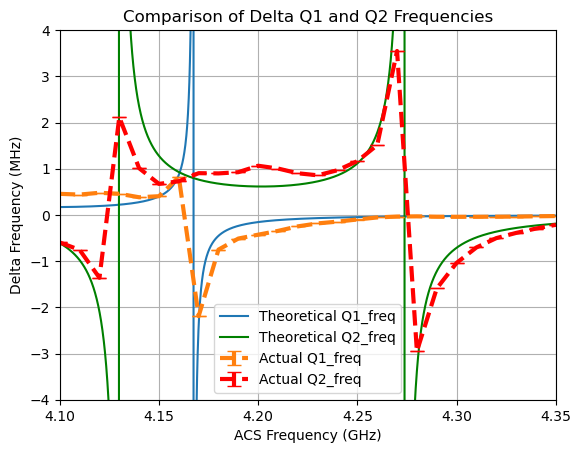

-487412.84610274143
487412.8461040362


In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Define the frequency range for the new ACS_freq
freq_start = 4.0e9  # Start frequency in Hz
freq_end = 4.4e9    # End frequency in Hz
freq_step = 0.1e6   # Step size in Hz
ACS_freq_th = np.arange(freq_start, freq_end, freq_step)

# Calculate delta_Q frequencies for the new ACS_freq
delta_Q1_freq_th = delta_Q_freq(ACS_freq_th, cf.Q1_freq, cf.Q1_ef_freq, scale_factor_Q1)
delta_Q2_freq_th = delta_Q_freq(ACS_freq_th, cf.Q2_freq, cf.Q2_ef_freq, scale_factor_Q2*1.4)

# Set the number of experiments (example, you should replace this with your actual value)
N_experiments = 1000  # Example, replace with actual value

# Estimated standard deviations (in MHz)
sigma_Q1 = 0.01
sigma_Q2 = 0.01

# Calculate the standard error (SEM) for each data point
Q1_errors = sigma_Q1 / np.sqrt(N_experiments)
Q2_errors = sigma_Q2 / np.sqrt(N_experiments)

# Combined plot for Q1 and Q2
plt.figure()

# Plot theoretical Q1 and Q2 data
plt.plot(ACS_freq_th * 10**-9, delta_Q1_freq_th * 10**-6, label='Theoretical Q1_freq')  # Theoretical Q1 curve
plt.plot(ACS_freq_th * 10**-9, delta_Q2_freq_th * 10**-6, label='Theoretical Q2_freq', color='green')  # Theoretical Q2 curve

# Plot actual Q1 data with error bars
plt.errorbar(ACS_freq * 10**-9, Q1_delta_freq_array * 10**-6, yerr=Q1_errors, label='Actual Q1_freq', fmt='--', linewidth=3, capsize=5)

# Plot actual Q2 data with error bars
plt.errorbar(ACS_freq * 10**-9, Q2_delta_freq_array * 10**-6, yerr=Q2_errors, label='Actual Q2_freq', fmt='--', linewidth=3, color='red', capsize=5)

# Optional vertical lines for references (e.g., ACS Frequency)
# plt.axvline(cf.ACS_freq * 10**-9, color='black', linestyle=':', label='ACS Frequency')
# plt.axvline(omega_s1 * 10**-9, color='purple', linestyle='-', label='ACS Theory')

plt.xlim(4.10, 4.35) 
plt.ylim(-4.0, 4.0) 
# Add labels, title, legend, and grid
plt.xlabel('ACS Frequency (GHz)')
plt.ylabel('Delta Frequency (MHz)')
plt.title('Comparison of Delta Q1 and Q2 Frequencies')
plt.legend()
plt.grid(True)
plt.show()

# Print delta Q frequencies at omega_s1 for Q1 and Q2
print(delta_Q_freq(omega_s1, cf.Q1_freq, cf.Q1_ef_freq, scale_factor_Q1))
print(delta_Q_freq(omega_s1, cf.Q2_freq, cf.Q2_ef_freq, scale_factor_Q2))


In [77]:
import os
import pandas as pd
from datetime import datetime

# Generate the date suffix dynamically with hour and minute
date_suffix = datetime.now().strftime('%m%d')  # Format: MMDD

exp_name = 'ACS_f_sweep'

# Define the date as a variable
# date_suffix = '1212'  # Set your desired date suffix here

# Define your directory where you want to save the files
save_directory = cf.save_load_dir

# # Make sure the directory exists, if not, create it
# os.makedirs(save_directory, exist_ok=True)

# Convert lists or arrays into pandas DataFrames for saving
df_delta_Q1_freq_th = pd.DataFrame(delta_Q1_freq_th, columns=['delta_Q1_freq_th'])
df_delta_Q2_freq_th = pd.DataFrame(delta_Q2_freq_th, columns=['delta_Q2_freq_th'])
df_ACS_freq_th = pd.DataFrame(ACS_freq_th, columns=['ACS_freq_th'])

# Save each DataFrame to a CSV file with the date suffix
df_delta_Q1_freq_th.to_csv(os.path.join(save_directory, f'{exp_name}_delta_Q1_freq_th_{date_suffix}.csv'), index=False)
df_delta_Q2_freq_th.to_csv(os.path.join(save_directory, f'{exp_name}_delta_Q2_freq_th_{date_suffix}.csv'), index=False)
df_ACS_freq_th.to_csv(os.path.join(save_directory, f'{exp_name}_ACS_freq_th_{date_suffix}.csv'), index=False)

print(f"Files have been saved to: {save_directory} with date suffix {date_suffix}")

Files have been saved to: C:/shared-root/users/Sean/xiayu11/calib_v6/Data with date suffix 0408
